In [1]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import sys, os
from autograd import grad, hessian
import autograd.numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
import pandas as pd
from utils import *
from sklearn.metrics import mean_squared_error
import matplotlib.colors as mcolors


In [2]:
#Load the data 
data = np.loadtxt( 'data.csv',delimiter = ',', skiprows=1)
labels = np.loadtxt( 'data_labels.csv',delimiter = ',', skiprows=1)
print(np.shape(data))

#Make the data into desired shape for sklearn (npoints, ndim)
x_data = data[:,]
y_data = labels

print(np.shape(x_data), np.shape(y_data))

#Feature transform: log the x-data
x_data[x_data <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf
x_data[:2, :] = np.log10(x_data[:2, :])

#Split into training and testing using 70% - 30% split
random_state = 20
x_data_og = x_data
X_train, X_test, y_train, y_test = train_test_split(x_data.T, y_data, test_size=0.30, random_state=random_state)
X_train_og, X_test_og = X_train, X_test
#Standard normalize the training data and use the mean and std to normalize the testing data
knn_scaler = StandardScaler().fit(X_train)
X_train = knn_scaler.transform(X_train)
X_test = knn_scaler.transform(X_test)

print("Training set ", np.shape(X_train), np.shape(y_train))
print("Testing set ", np.shape(X_test), np.shape(y_test))

(4, 14187)
(4, 14187) (14187,)
Training set  (9930, 4) (9930,)
Testing set  (4257, 4) (4257,)


In [3]:
estimator_KNN = KNeighborsClassifier(algorithm='auto')

parameters_KNN = {
    'n_neighbors': [3, 5, 10],
    'p': [1,2],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'chebyshev']}

grid_search_KNN = GridSearchCV(
    estimator= estimator_KNN,
    param_grid=parameters_KNN,
    scoring = 'balanced_accuracy',
    cv = 5)

parameters = {'kernel':[('rbf')], 'C':[0.01, 0.1, 1, 10, 100, 1000], 'gamma':[0.001, 0.01, 0.1, 1, 10]}

grid_search_KNN.fit(X_train, y_train)
best_model_knn = grid_search_KNN.best_estimator_

print(grid_search_KNN.best_params_)

{'metric': 'minkowski', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}


In [4]:
y_pred = best_model_knn.predict(X_test)

print("Test Accuracy: {:.3f}%".format(accuracy_score(y_test, y_pred)*100))
print("Test Balanced Accuracy: {:.3f}%".format(balanced_accuracy_score(y_test, y_pred)*100))

Test Accuracy: 95.114%
Test Balanced Accuracy: 91.494%


[[1.         1.         1.         ... 0.4        0.5        0.7       ]
 [1.         1.         1.         ... 1.70000085 2.         2.5       ]]
(2, 290)


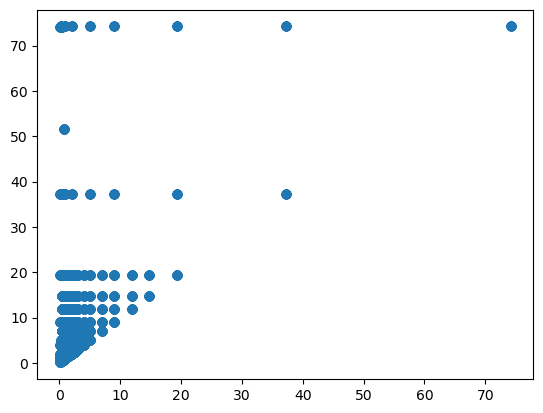

In [5]:
masses = x_data_og[2:,:]
masses[1, :] = masses[0, :] / masses[1, :]

plt.scatter(masses[0, :], masses[1, :])
print((masses))
unique_rows = np.unique(masses, axis=1)
print((np.shape(unique_rows)))

/Users/elenagonzalez/Desktop/Research/ML/utils.py:338: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_filtered[:, feature_idx[0]], X_test_filtered[:, feature_idx[1]],  c=y_test_filtered, cmap='coolwarm', edgecolor="k" , marker='x', label = 'Test')


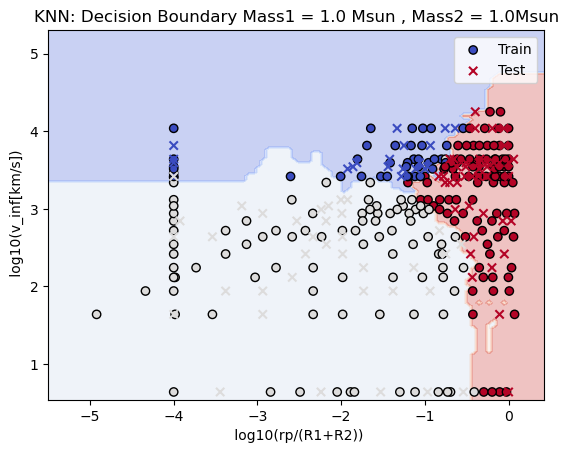

In [6]:
# unique_rows = unique_rows.T
import matplotlib.colors as mcolors
unique_rows = np.array([[1.0,1.0]])
for unique in unique_rows:
    Mass1 = unique[0]
    Mass2 = unique[1]
    # labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    labels = ['log10(rp/(R1+R2))', 'log10(v_inf[km/s])', str(Mass1), str(round(Mass2,2))]
    N_knn_gridsearch_plotter(X_train_og, y_train, X_test_og ,y_test, best_model_knn, knn_scaler,feature_idx=(0, 1), fixed_values={2: Mass1, 3: Mass1/Mass2}, labels = labels)